#  Super-Resolution via Diffusion Model


In [1]:
!pip install -q diffusers accelerate torchmetrics lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 1.9 MB/s eta 0:00:00


In [2]:
import os, math, random, warnings
from copy import deepcopy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision.utils import make_grid

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


##  2. Configuration

In [3]:
class Config:
    DATA_DIR      = '/kaggle/input/datasets/joe1995/div2k-dataset'          
    HR_SIZE       = 128                      
    LR_SIZE       = 24                       
    VAL_RATIO     = 0.05

    # Model
    BASE_CHANNELS = 64
    CHANNEL_MULTS = (1, 2, 4, 8)            
    ATTN_RES      = (16,)                    
    DROPOUT       = 0.1

    # Diffusion
    TIMESTEPS     = 1000
    BETA_SCHEDULE = 'cosine'                

    # Training
    EPOCHS        = 100
    BATCH_SIZE    = 8
    LR            = 2e-4
    EMA_DECAY     = 0.9999
    AMP           = True                     
    NUM_WORKERS   = 2
    VAL_EVERY     = 5                        
    DDIM_STEPS    = 50                       
    ETA           = 0.0                      

    # Paths
    SAVE_DIR      = '/kaggle/working/checkpoints'
    SAMPLE_DIR    = '/kaggle/working/samples'

    SEED          = 42

cfg = Config()

# Reproducibility
random.seed(cfg.SEED)
np.random.seed(cfg.SEED)
torch.manual_seed(cfg.SEED)
torch.cuda.manual_seed_all(cfg.SEED)

os.makedirs(cfg.SAVE_DIR,  exist_ok=True)
os.makedirs(cfg.SAMPLE_DIR, exist_ok=True)
print('Config ready')

Config ready


##  3. Dataset & Data Loading

In [4]:
class SRDataset(Dataset):
    EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

    def __init__(self, root, hr_size=128, lr_size=24,
                 split='train', val_ratio=0.05, augment=True):
        self.hr_size = hr_size
        self.lr_size = lr_size
        self.augment = augment and (split == 'train')

        all_paths = sorted([
            p for p in Path(root).rglob('*')
            if p.suffix.lower() in self.EXTS
        ])
        if not all_paths:
            raise FileNotFoundError(f'No images found in {root}')

        rng = random.Random(42)
        rng.shuffle(all_paths)
        n_val = max(1, int(len(all_paths) * val_ratio))
        self.paths = all_paths[:n_val] if split == 'val' else all_paths[n_val:]

        self.to_tensor = T.ToTensor()
        self.norm      = T.Normalize([0.5]*3, [0.5]*3)

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img  = Image.open(self.paths[idx]).convert('RGB')
        w, h = img.size
        img  = TF.center_crop(img, min(w, h))
        hr   = img.resize((self.hr_size, self.hr_size), Image.BICUBIC)

        if self.augment:
            if random.random() > 0.5: hr = TF.hflip(hr)
            hr = TF.rotate(hr, random.choice([0, 90, 180, 270]))

        lr    = hr.resize((self.lr_size, self.lr_size), Image.BICUBIC)
        lr_up = lr.resize((self.hr_size, self.hr_size), Image.BICUBIC)

        t = lambda x: self.norm(self.to_tensor(x))
        return {'hr': t(hr), 'lr': t(lr), 'lr_up': t(lr_up)}



train_ds = SRDataset(cfg.DATA_DIR, cfg.HR_SIZE, cfg.LR_SIZE, 'train', cfg.VAL_RATIO)
val_ds   = SRDataset(cfg.DATA_DIR, cfg.HR_SIZE, cfg.LR_SIZE, 'val',   cfg.VAL_RATIO, augment=False)

train_dl = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                      num_workers=cfg.NUM_WORKERS, pin_memory=True, drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=4,             shuffle=False,
                      num_workers=cfg.NUM_WORKERS, pin_memory=True)

print(f'Train: {len(train_ds)} images  |  Val: {len(val_ds)} images')

# Quick sanity check
batch = next(iter(train_dl))
print(f'HR shape   : {batch["hr"].shape}')    # (B, 3, 128, 128)
print(f'LR shape   : {batch["lr"].shape}')    # (B, 3,  24,  24)
print(f'LR_up shape: {batch["lr_up"].shape}') # (B, 3, 128, 128)
print(f'Value range: [{batch["hr"].min():.2f}, {batch["hr"].max():.2f}]')

Train: 1710 images  |  Val: 90 images
HR shape   : torch.Size([8, 3, 128, 128])
LR shape   : torch.Size([8, 3, 24, 24])
LR_up shape: torch.Size([8, 3, 128, 128])
Value range: [-1.00, 1.00]


##  4. Model — Conditional U-Net



In [5]:
def sinusoidal_embedding(timesteps, dim):
    half = dim // 2
    freq = torch.exp(
        -math.log(10000) * torch.arange(half, dtype=torch.float32, device=timesteps.device) / half
    )
    emb = timesteps.float()[:, None] * freq[None, :]
    return torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)


class Swish(nn.Module):
    def forward(self, x): return x * x.sigmoid()


class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim * 4), Swish(),
            nn.Linear(dim * 4, dim * 4)
        )
        self.dim = dim

    def forward(self, t):
        return self.net(sinusoidal_embedding(t, self.dim))


class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, t_dim, dropout=0.1):
        super().__init__()
        self.block1    = nn.Sequential(nn.GroupNorm(8, in_ch),  Swish(), nn.Conv2d(in_ch,  out_ch, 3, padding=1))
        self.t_proj    = nn.Linear(t_dim, out_ch)
        self.block2    = nn.Sequential(nn.GroupNorm(8, out_ch), Swish(), nn.Dropout(dropout), nn.Conv2d(out_ch, out_ch, 3, padding=1))
        self.shortcut  = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.block1(x) + self.t_proj(t_emb)[:, :, None, None]
        return self.block2(h) + self.shortcut(x)


class SelfAttention(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.norm  = nn.GroupNorm(8, ch)
        self.qkv   = nn.Conv2d(ch, ch * 3, 1)
        self.proj  = nn.Conv2d(ch, ch, 1)
        self.scale = ch ** -0.5

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        q, k, v = self.qkv(h).view(B, 3, C, -1).unbind(1)   # (B, C, HW)
        attn = (q.permute(0,2,1) @ k) * self.scale           # (B, HW, HW)
        attn = attn.softmax(-1)
        out  = (v @ attn.permute(0,2,1)).view(B, C, H, W)
        return x + self.proj(out)


class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, t_dim, use_attn=False):
        super().__init__()
        self.res   = ResidualBlock(in_ch, out_ch, t_dim)
        self.attn  = SelfAttention(out_ch) if use_attn else nn.Identity()
        self.down  = nn.Conv2d(out_ch, out_ch, 3, stride=2, padding=1)

    def forward(self, x, t):
        x    = self.attn(self.res(x, t))
        skip = x
        return self.down(x), skip


class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, t_dim, use_attn=False):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, in_ch, 4, stride=2, padding=1)
        self.res  = ResidualBlock(in_ch + skip_ch, out_ch, t_dim)
        self.attn = SelfAttention(out_ch) if use_attn else nn.Identity()

    def forward(self, x, skip, t):
        x = torch.cat([self.up(x), skip], dim=1)
        return self.attn(self.res(x, t))

In [6]:
class SRUNet(nn.Module):
    def __init__(
        self,
        in_ch: int          = 6,
        out_ch: int         = 3,
        base_channels: int  = 64,
        channel_mults: tuple= (1, 2, 4, 8),
        attn_res: tuple     = (16,),
        dropout: float      = 0.1,
        image_size: int     = 128,
    ):
        super().__init__()
        t_dim = base_channels * 4
        self.time_embed = TimeEmbedding(base_channels)
        self.init_conv = nn.Conv2d(in_ch, base_channels, 3, padding=1)
        self.downs    = nn.ModuleList()
        ch_list = [base_channels]
        ch, res = base_channels, image_size

        for mult in channel_mults:
            out = base_channels * mult
            self.downs.append(
                DownBlock(ch, out, t_dim, use_attn=(res in attn_res))
            )
            ch  = out
            res = res // 2
            ch_list.append(ch)
        self.mid = nn.ModuleList([
            ResidualBlock(ch, ch, t_dim, dropout),
            SelfAttention(ch),
            ResidualBlock(ch, ch, t_dim, dropout),
        ])
        self.ups = nn.ModuleList()
        for mult in reversed(channel_mults):
            skip_ch = ch_list.pop()
            out     = base_channels * mult
            self.ups.append(
                UpBlock(ch, skip_ch, out, t_dim, use_attn=(res in attn_res))
            )
            ch  = out
            res = res * 2
        self.out = nn.Sequential(
            nn.GroupNorm(8, ch), Swish(),
            nn.Conv2d(ch, out_ch, 3, padding=1)
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_emb = self.time_embed(t)   # (B, 4*C)
        x     = self.init_conv(x)    # (B, C, H, W)

        # Encoder
        skips = []
        for down in self.downs:
            x, skip = down(x, t_emb)
            skips.append(skip)

        # Bottleneck
        x = self.mid[0](x, t_emb)
        x = self.mid[1](x)
        x = self.mid[2](x, t_emb)

        # Decoder
        for up in self.ups:
            x = up(x, skips.pop(), t_emb)

        return self.out(x)

model = SRUNet(
    base_channels = cfg.BASE_CHANNELS,
    channel_mults = cfg.CHANNEL_MULTS,
    attn_res      = cfg.ATTN_RES,
    dropout       = cfg.DROPOUT,
    image_size    = cfg.HR_SIZE,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters : {total_params/1e6:.2f}M')

# Smoke test
with torch.no_grad():
    dummy_x = torch.randn(2, 6, cfg.HR_SIZE, cfg.HR_SIZE).to(DEVICE)
    dummy_t = torch.randint(0, 1000, (2,)).to(DEVICE)
    out = model(dummy_x, dummy_t)
print(f'Input  : {dummy_x.shape}  →  Output : {out.shape}')

Model parameters : 41.35M
Input  : torch.Size([2, 6, 128, 128])  →  Output : torch.Size([2, 3, 128, 128])


##  5. Diffusion Process (DDPM + DDIM)

In [7]:
class GaussianDiffusion:
    def __init__(self, timesteps=1000, beta_schedule='cosine'):
        self.T = timesteps
        if beta_schedule == 'cosine':
            steps  = timesteps + 1
            x      = torch.linspace(0, timesteps, steps)
            ab     = torch.cos(((x / timesteps) + 0.008) / 1.008 * math.pi * 0.5) ** 2
            ab     = ab / ab[0]
            betas  = (1 - ab[1:] / ab[:-1]).clamp(1e-4, 0.9999)
        else:  # linear
            betas  = torch.linspace(1e-4, 0.02, timesteps)

        alphas     = 1. - betas
        alpha_bar  = torch.cumprod(alphas, 0)
        alpha_bar_prev = F.pad(alpha_bar[:-1], (1, 0), value=1.)

        # Store all schedule tensors
        self.betas             = betas.float()
        self.alpha_bar         = alpha_bar.float()
        self.alpha_bar_prev    = alpha_bar_prev.float()
        self.sqrt_ab           = alpha_bar.sqrt().float()
        self.sqrt_one_minus_ab = (1. - alpha_bar).sqrt().float()
        self.post_var          = (betas * (1. - alpha_bar_prev) / (1. - alpha_bar)).float()
        self.post_coef1        = (betas * alpha_bar_prev.sqrt() / (1. - alpha_bar)).float()
        self.post_coef2        = ((1. - alpha_bar_prev) * alphas.sqrt() / (1. - alpha_bar)).float()
    def _g(self, arr, t, shape):
        return arr.to(t.device).gather(0, t).view(t.shape[0], *([1]*(len(shape)-1)))
    def q_sample(self, x0, t, noise=None):
        if noise is None: noise = torch.randn_like(x0)
        return (self._g(self.sqrt_ab, t, x0.shape) * x0
              + self._g(self.sqrt_one_minus_ab, t, x0.shape) * noise), noise

    def p_losses(self, model, x0, lr_up, t):
        noise  = torch.randn_like(x0)
        x_t, _ = self.q_sample(x0, t, noise)
        pred   = model(torch.cat([x_t, lr_up], dim=1), t)
        return F.mse_loss(pred, noise)
    @torch.no_grad()
    def p_sample(self, model, x_t, lr_up, t_idx):
        B  = x_t.shape[0]
        t  = torch.full((B,), t_idx, dtype=torch.long, device=x_t.device)
        ep = model(torch.cat([x_t, lr_up], dim=1), t)

        # Reconstruct x0
        x0 = (x_t - self._g(self.sqrt_one_minus_ab, t, x_t.shape) * ep) \
           /  self._g(self.sqrt_ab, t, x_t.shape)
        x0 = x0.clamp(-1, 1)

        mean = (self._g(self.post_coef1, t, x_t.shape) * x0
              + self._g(self.post_coef2, t, x_t.shape) * x_t)
        return mean if t_idx == 0 else mean + self._g(self.post_var, t, x_t.shape).sqrt() * torch.randn_like(x_t)
    @torch.no_grad()
    def ddim_sample(self, model, lr_up, shape, device, steps=50, eta=0., verbose=True):
        model.eval()
        x        = torch.randn(shape, device=device)
        t_seq    = list(reversed(range(0, self.T, self.T // steps)))

        for i, t_idx in enumerate(tqdm(t_seq, desc='DDIM', disable=not verbose)):
            t   = torch.full((shape[0],), t_idx, dtype=torch.long, device=device)
            ep  = model(torch.cat([x, lr_up], dim=1), t)

            ab    = self._g(self.alpha_bar, t, x.shape)
            x0    = ((x - (1-ab).sqrt() * ep) / ab.sqrt()).clamp(-1, 1)

            if i < len(t_seq) - 1:
                t_p  = torch.full((shape[0],), t_seq[i+1], dtype=torch.long, device=device)
                ab_p = self._g(self.alpha_bar, t_p, x.shape)
            else:
                ab_p = torch.ones_like(ab)

            sigma = eta * ((1-ab_p)/(1-ab) * (1-ab/ab_p)).clamp(min=0).sqrt()
            x     = ab_p.sqrt() * x0 + (1-ab_p-sigma**2).clamp(min=0).sqrt() * ep
            if eta > 0: x = x + sigma * torch.randn_like(x)

        return x


diffusion = GaussianDiffusion(cfg.TIMESTEPS, cfg.BETA_SCHEDULE)

# Quick loss test
with torch.no_grad():
    t_    = torch.randint(0, cfg.TIMESTEPS, (2,)).to(DEVICE)
    hr_   = torch.randn(2, 3, cfg.HR_SIZE, cfg.HR_SIZE).to(DEVICE)
    lrup_ = torch.randn(2, 3, cfg.HR_SIZE, cfg.HR_SIZE).to(DEVICE)
    loss_ = diffusion.p_losses(model, hr_, lrup_, t_)
print(f'Diffusion test loss: {loss_.item():.4f}')

Diffusion test loss: 1.0931


##  6. Training

In [8]:
class EMA:
    def __init__(self, model, decay=0.9999):
        self.decay  = decay
        self.shadow = deepcopy(model).eval()
        for p in self.shadow.parameters(): p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        for s, m in zip(self.shadow.parameters(), model.parameters()):
            s.data.mul_(self.decay).add_(m.data, alpha=1 - self.decay)


def psnr(pred, target):
    return 10 * torch.log10(4. / ((pred - target)**2).mean().clamp(min=1e-8))


def denorm(t):
    return (t.clamp(-1, 1) + 1) / 2

In [9]:
optimizer = optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS)
scaler    = GradScaler(enabled=cfg.AMP)
ema       = EMA(model, cfg.EMA_DECAY)

train_losses, val_psnrs = [], []
best_psnr = 0.

for epoch in range(1, cfg.EPOCHS + 1):
    model.train()
    epoch_loss = 0.
    pbar = tqdm(train_dl, desc=f'Epoch {epoch}/{cfg.EPOCHS}', leave=False)

    for batch in pbar:
        hr    = batch['hr'].to(DEVICE)
        lr_up = batch['lr_up'].to(DEVICE)
        t     = torch.randint(0, diffusion.T, (hr.shape[0],), device=DEVICE)

        optimizer.zero_grad()
        with autocast(enabled=cfg.AMP):
            loss = diffusion.p_losses(model, hr, lr_up, t)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        ema.update(model)

        epoch_loss += loss.item()
        pbar.set_postfix(loss=f'{loss.item():.4f}')

    scheduler.step()
    avg_loss = epoch_loss / len(train_dl)
    train_losses.append(avg_loss)

    if epoch % cfg.VAL_EVERY == 0:
        ema_model = ema.shadow.to(DEVICE)
        ema_model.eval()
        val_psnr_sum = 0.

        with torch.no_grad():
            for vi, vbatch in enumerate(val_dl):
                hr_v    = vbatch['hr'].to(DEVICE)
                lr_up_v = vbatch['lr_up'].to(DEVICE)
                gen     = diffusion.ddim_sample(
                    ema_model, lr_up_v,
                    shape=hr_v.shape, device=DEVICE,
                    steps=cfg.DDIM_STEPS, eta=cfg.ETA, verbose=False
                )
                val_psnr_sum += psnr(gen, hr_v).item()

                if vi == 0:
                    grid = make_grid(
                        torch.cat([denorm(lr_up_v[:4]), denorm(gen[:4]), denorm(hr_v[:4])]),
                        nrow=4
                    )
                    from torchvision.transforms.functional import to_pil_image
                    to_pil_image(grid).save(f'{cfg.SAMPLE_DIR}/epoch_{epoch:04d}.png')

        val_psnr = val_psnr_sum / len(val_dl)
        val_psnrs.append((epoch, val_psnr))
        print(f'Epoch {epoch:4d} | Loss {avg_loss:.4f} | Val PSNR {val_psnr:.2f} dB')

        if val_psnr > best_psnr:
            best_psnr = val_psnr
            torch.save({'epoch': epoch, 'model': model.state_dict(),
                        'ema': ema.shadow.state_dict()},
                       f'{cfg.SAVE_DIR}/best.pt')
            print(f'  New best checkpoint saved ({val_psnr:.2f} dB)')
    else:
        print(f'Epoch {epoch:4d} | Loss {avg_loss:.4f}')

    # Latest checkpoint
    torch.save({'epoch': epoch, 'model': model.state_dict(),
                'ema': ema.shadow.state_dict()},
               f'{cfg.SAVE_DIR}/latest.pt')

print(f'\n Training complete. Best Val PSNR: {best_psnr:.2f} dB')

Epoch 1/100:   0%|          | 0/213 [00:00<?, ?it/s]

Epoch    1 | Loss 0.1933


Epoch 2/100:   0%|          | 0/213 [00:00<?, ?it/s]

Epoch    2 | Loss 0.1025


Epoch 3/100:   0%|          | 0/213 [00:00<?, ?it/s]

...

Epoch   98 | Loss 0.0478


Epoch 99/100:   0%|          | 0/213 [00:00<?, ?it/s]

Epoch   99 | Loss 0.0491


Epoch 100/100:   0%|          | 0/213 [00:00<?, ?it/s]

Epoch  100 | Loss 0.0508 | Val PSNR 17.67 dB
  New best checkpoint saved (17.67 dB)

 Training complete. Best Val PSNR: 17.67 dB


##  7. Training Curves

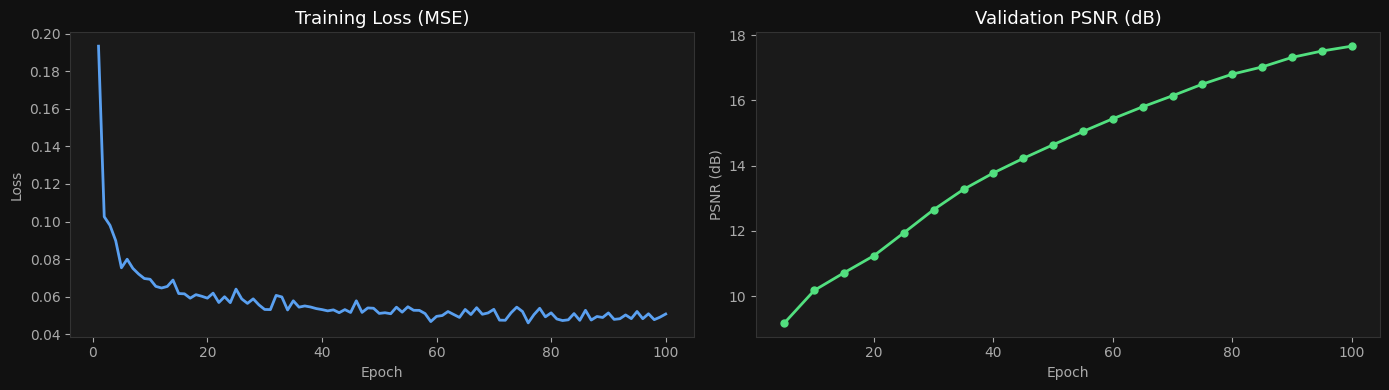

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), facecolor='#111')

ax1.plot(range(1, len(train_losses)+1), train_losses, color='#5aa0f0', lw=2)
ax1.set_title('Training Loss (MSE)', color='white', fontsize=13)
ax1.set_xlabel('Epoch', color='#aaa'); ax1.set_ylabel('Loss', color='#aaa')
ax1.tick_params(colors='#aaa'); ax1.set_facecolor('#1a1a1a')
for s in ax1.spines.values(): s.set_edgecolor('#333')

if val_psnrs:
    ep, ps = zip(*val_psnrs)
    ax2.plot(ep, ps, color='#52e07f', lw=2, marker='o', ms=5)
    ax2.set_title('Validation PSNR (dB)', color='white', fontsize=13)
    ax2.set_xlabel('Epoch', color='#aaa'); ax2.set_ylabel('PSNR (dB)', color='#aaa')
    ax2.tick_params(colors='#aaa'); ax2.set_facecolor('#1a1a1a')
    for s in ax2.spines.values(): s.set_edgecolor('#333')

plt.tight_layout()
plt.savefig(f'{cfg.SAMPLE_DIR}/training_curves.png', bbox_inches='tight', dpi=120, facecolor='#111')
plt.show()

##  8. Inference — Ground Truth | LR 24×24 | Diffusion SR



Loaded: /kaggle/working/checkpoints/best.pt


DDIM:   0%|          | 0/50 [00:00<?, ?it/s]

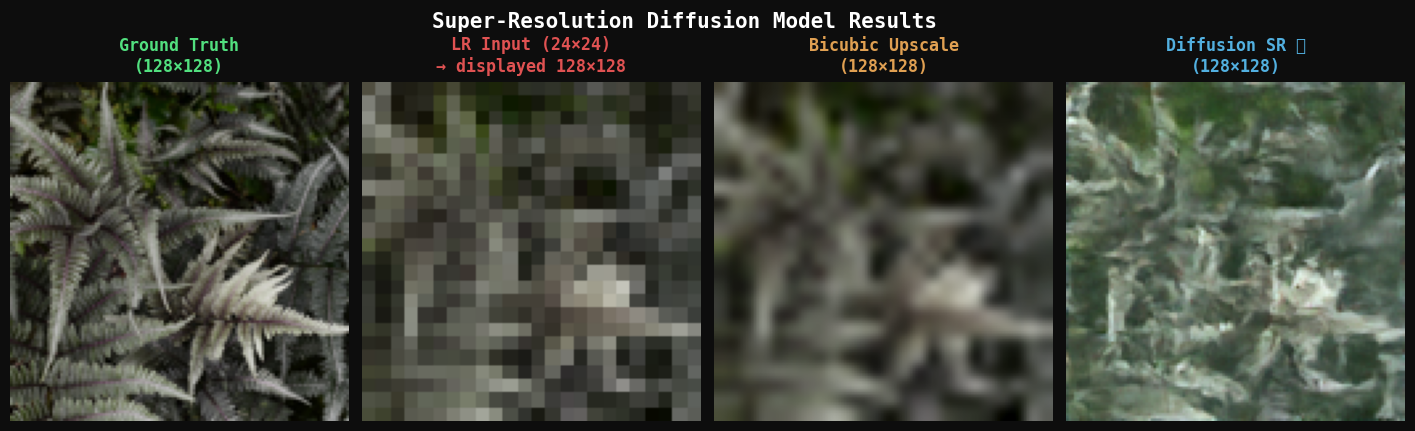

Saved → /kaggle/working/samples/inference_result.png


In [11]:
def prepare_single_image(image_path, hr_size=128, lr_size=24):
    norm      = T.Normalize([0.5]*3, [0.5]*3)
    to_tensor = T.ToTensor()

    img  = Image.open(image_path).convert('RGB')
    w, h = img.size
    img  = TF.center_crop(img, min(w, h))
    hr   = img.resize((hr_size, hr_size), Image.BICUBIC)
    lr   = hr.resize((lr_size,  lr_size),  Image.BICUBIC)
    lr_up = lr.resize((hr_size, hr_size), Image.BICUBIC)

    hr_t    = norm(to_tensor(hr)).unsqueeze(0)
    lr_up_t = norm(to_tensor(lr_up)).unsqueeze(0)
    return hr_t, lr, lr_up_t, hr


def show_results(image_path, checkpoint=None,
                 hr_size=128, lr_size=24,
                 ddim_steps=50, eta=0.):
    # Load model
    m = SRUNet(base_channels=cfg.BASE_CHANNELS, channel_mults=cfg.CHANNEL_MULTS,
               image_size=hr_size).to(DEVICE)
    if checkpoint:
        ckpt  = torch.load(checkpoint, map_location=DEVICE)
        state = ckpt.get('ema', ckpt.get('model', ckpt))
        m.load_state_dict(state)
        print(f'Loaded: {checkpoint}')
    m.eval()

    diff = GaussianDiffusion(cfg.TIMESTEPS, cfg.BETA_SCHEDULE)

    # Prepare inputs
    hr_t, lr_pil, lr_up_t, hr_pil = prepare_single_image(image_path, hr_size, lr_size)
    lr_up_t = lr_up_t.to(DEVICE)

    # Generate
    with torch.no_grad():
        gen_t = diff.ddim_sample(m, lr_up_t, shape=(1,3,hr_size,hr_size),
                                  device=DEVICE, steps=ddim_steps, eta=eta)

    def t2pil(t):
        arr = (t.squeeze(0).clamp(-1,1).permute(1,2,0).cpu().numpy() + 1) / 2
        return Image.fromarray((arr*255).astype(np.uint8))

    panels = [
        (hr_pil,                              f'Ground Truth\n({hr_size}×{hr_size})',    '#52e07f'),
        (lr_pil.resize((hr_size,hr_size), Image.NEAREST), f'LR Input (24×24)\n→ displayed {hr_size}×{hr_size}', '#e05252'),
        (t2pil(lr_up_t.cpu()),                f'Bicubic Upscale\n({hr_size}×{hr_size})', '#e0a052'),
        (t2pil(gen_t),                         f'Diffusion SR ✨\n({hr_size}×{hr_size})',  '#52b0e0'),
    ]

    fig = plt.figure(figsize=(18, 5), facecolor='#0d0d0d')
    gs  = gridspec.GridSpec(1, 4, wspace=0.04)
    for i, (img, title, color) in enumerate(panels):
        ax = fig.add_subplot(gs[i])
        ax.imshow(np.array(img))
        ax.set_title(title, color=color, fontsize=12, fontweight='bold', fontfamily='monospace', pad=8)
        ax.axis('off')
        for s in ax.spines.values():
            s.set_visible(True); s.set_edgecolor(color); s.set_linewidth(2.5)

    fig.suptitle('Super-Resolution Diffusion Model Results',
                 color='white', fontsize=15, fontweight='bold', fontfamily='monospace')
    plt.tight_layout()
    out_path = f'{cfg.SAMPLE_DIR}/inference_result.png'
    plt.savefig(out_path, bbox_inches='tight', dpi=150, facecolor='#0d0d0d')
    plt.show()
    print(f'Saved → {out_path}')
# Replace with your actual image path:
TEST_IMAGE = '/kaggle/input/datasets/joe1995/div2k-dataset/DIV2K_valid_HR/DIV2K_valid_HR/0840.png'
CKPT_PATH  = f'{cfg.SAVE_DIR}/best.pt'

if os.path.exists(TEST_IMAGE):
    show_results(
        image_path  = TEST_IMAGE,
        checkpoint  = CKPT_PATH if os.path.exists(CKPT_PATH) else None,
        hr_size     = cfg.HR_SIZE,
        lr_size     = cfg.LR_SIZE,
        ddim_steps  = cfg.DDIM_STEPS,
        eta         = cfg.ETA,
    )
else:
    print(f'Set TEST_IMAGE to a valid path. Current: {TEST_IMAGE}')

##  9. Fine-Tuning on a Pretrained Checkpoint

In [12]:
FINETUNE_CKPT = f'{cfg.SAVE_DIR}/latest.pt'
FINETUNE_LR   = 5e-5    # lower LR for fine-tuning
FINETUNE_EPOCHS = 20

if os.path.exists(FINETUNE_CKPT):
    ckpt = torch.load(FINETUNE_CKPT, map_location=DEVICE)
    model.load_state_dict(ckpt['model'])
    ema.shadow.load_state_dict(ckpt['ema'])
    print(f'Loaded checkpoint from epoch {ckpt["epoch"]} for fine-tuning')

    ft_optimizer = optim.AdamW(model.parameters(), lr=FINETUNE_LR, weight_decay=1e-4)
    ft_scheduler = optim.lr_scheduler.CosineAnnealingLR(ft_optimizer, T_max=FINETUNE_EPOCHS)
    ft_scaler    = GradScaler(enabled=cfg.AMP)

    for ep in range(1, FINETUNE_EPOCHS + 1):
        model.train()
        ep_loss = 0.
        for batch in tqdm(train_dl, desc=f'FT Epoch {ep}/{FINETUNE_EPOCHS}', leave=False):
            hr    = batch['hr'].to(DEVICE)
            lr_up = batch['lr_up'].to(DEVICE)
            t     = torch.randint(0, diffusion.T, (hr.shape[0],), device=DEVICE)

            ft_optimizer.zero_grad()
            with autocast(enabled=cfg.AMP):
                loss = diffusion.p_losses(model, hr, lr_up, t)
            ft_scaler.scale(loss).backward()
            ft_scaler.unscale_(ft_optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            ft_scaler.step(ft_optimizer)
            ft_scaler.update()
            ema.update(model)
            ep_loss += loss.item()

        ft_scheduler.step()
        print(f'FT Epoch {ep:3d} | Loss {ep_loss/len(train_dl):.4f}')

    torch.save({'model': model.state_dict(), 'ema': ema.shadow.state_dict()},
               f'{cfg.SAVE_DIR}/finetuned.pt')
    print('Fine-tuning complete')
else:
    print('No checkpoint found — train first!')

Loaded checkpoint from epoch 100 for fine-tuning


FT Epoch 1/20:   0%|          | 0/213 [00:00<?, ?it/s]

FT Epoch   1 | Loss 0.0493


FT Epoch 2/20:   0%|          | 0/213 [00:00<?, ?it/s]

FT Epoch   2 | Loss 0.0476


...

FT Epoch  18 | Loss 0.0505


FT Epoch 19/20:   0%|          | 0/213 [00:00<?, ?it/s]

FT Epoch  19 | Loss 0.0530


FT Epoch 20/20:   0%|          | 0/213 [00:00<?, ?it/s]

FT Epoch  20 | Loss 0.0480
Fine-tuning complete


In [13]:
import torch

# Define the path where you want to save the production model
SAVE_PATH = '/kaggle/working/diffusion_sr_model.pth'

# Use EMA weights for better inference quality
model_to_save = ema.shadow.state_dict()

torch.save({
    'model_state_dict': model_to_save,
    'config': {
        'base_channels': cfg.BASE_CHANNELS,
        'channel_mults': cfg.CHANNEL_MULTS,
        'image_size': cfg.HR_SIZE
    }
}, SAVE_PATH)

print(f"Model saved for application use at: {SAVE_PATH}")

Model saved for application use at: /kaggle/working/diffusion_sr_model.pth


Loaded: /kaggle/working/checkpoints/best.pt


DDIM:   0%|          | 0/50 [00:00<?, ?it/s]

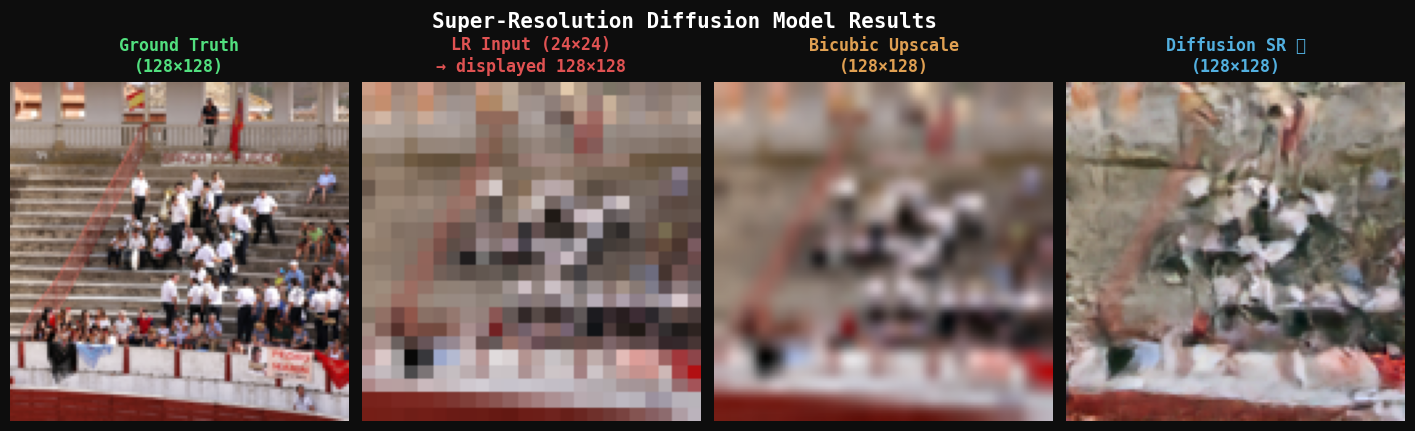

Saved → /kaggle/working/samples/inference_result.png


In [14]:
CKPT_PATH = '/kaggle/working/checkpoints/best.pt'

TEST_IMAGE = '/kaggle/input/datasets/joe1995/div2k-dataset/DIV2K_valid_HR/DIV2K_valid_HR/0825.png'

if os.path.exists(TEST_IMAGE):
    show_results(
        image_path=TEST_IMAGE, 
        checkpoint=CKPT_PATH, 
        hr_size=cfg.HR_SIZE, 
        lr_size=cfg.LR_SIZE, 
        ddim_steps=50, 
        eta=0.0        
    )
else:
    print("Check your image path!")